In [1]:
%matplotlib inline

# scientific computing and plotting
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns

# HDDM related packages
import pymc as pm
import hddm
import kabuki
import arviz as az
print("The current HDDM version is: ", hddm.__version__)
print("The current kabuki version is: ", kabuki.__version__)
print("The current PyMC version is: ", pm.__version__)
print("The current ArviZ version is: ", az.__version__)

import warnings
warnings.filterwarnings('ignore') 

The current HDDM version is:  1.0.1RC
The current kabuki version is:  0.6.5RC4
The current PyMC version is:  2.3.8
The current ArviZ version is:  0.15.1


In [2]:
# read data
data = pd.read_csv('MS_categ_id_hddm_stim.csv')
data

,subj_idx,val,id,stim,response,rt
0,7304,Good,Self,1,1,0.4236
1,7304,Bad,Other,0,0,0.5631
2,7304,Bad,Self,1,1,0.7198
3,7304,Good,Other,0,0,0.6799
4,7304,Good,Self,1,1,0.3560
...,...,...,...,...,...,...
14488,7345,Good,Other,0,0,0.3472
14489,7345,Bad,Self,1,1,0.4249
14490,7345,Bad,Self,1,1,0.3351
14491,7345,Bad,Other,0,0,0.4232


In [5]:
#load model
hddm_id_acc = hddm.load('hddm_id_m0_acc_diff.hddm')
hddm_id_choice = hddm.load('hddm_id_m1_choice_diff.hddm')
stim_dc = hddm.load('hddmStim_vflip_dc_m1.hddm')
stim_zflip = hddm.load('hddmStim_zflip_m1_diff.hddm')
reg_id_acc = hddm.load('hddmReg_id_m0_acc_diff.hddm')
reg_id_choice = hddm.load('hddmReg_id_m2_choice_diff.hddm')
reg_dc = hddm.load('hddmReg_stim_vflip_dc_m2.hddm')
reg_vflip = hddm.load('hddmReg_stim_vflip_m3_diff.hddm')
reg_zflip = hddm.load('hddmReg_stim_zflip_m2_diff.hddm')

In [6]:
ppc_data_hddm_acc = hddm.utils.post_pred_gen(hddm_id_acc, progress_bar=True)
ppc_data_hddm_choice = hddm.utils.post_pred_gen(hddm_id_choice, progress_bar=True)
ppc_data_stim_dc = hddm.utils.post_pred_gen(stim_dc, progress_bar=True)
ppc_data_stim_zflip = hddm.utils.post_pred_gen(stim_zflip)
ppc_data_reg_acc = hddm.utils.post_pred_gen(reg_id_acc, progress_bar=True)
ppc_data_reg_choice = hddm.utils.post_pred_gen(reg_id_choice, progress_bar=True)
ppc_data_reg_dc = hddm.utils.post_pred_gen(reg_dc, progress_bar=True)
ppc_data_reg_vflip = hddm.utils.post_pred_gen(reg_vflip, progress_bar=True)
ppc_data_reg_zflip = hddm.utils.post_pred_gen(reg_zflip, progress_bar=True)

Start generating posterior prediction...
Start generating posterior prediction...
Start generating posterior prediction...
Start generating posterior prediction...
Start generating posterior prediction...
Start generating posterior prediction...
Start generating posterior prediction...
Start generating posterior prediction...
Start generating posterior prediction...


In [9]:
# ====================== Save all PPC data locally ======================
import pickle

# Store all PPC data in a dictionary for saving
ppc_all_data = {
    "ppc_data_hddm_acc": ppc_data_hddm_acc,
    "ppc_data_hddm_choice": ppc_data_hddm_choice,
    "ppc_data_stim_dc": ppc_data_stim_dc,
    "ppc_data_stim_zflip": ppc_data_stim_zflip,
    "ppc_data_reg_acc": ppc_data_reg_acc,
    "ppc_data_reg_choice": ppc_data_reg_choice,
    "ppc_data_reg_dc": ppc_data_reg_dc,
    "ppc_data_reg_vflip": ppc_data_reg_vflip,
    "ppc_data_reg_zflip": ppc_data_reg_zflip,
}

# Save to file (file name: all_ppc_data.pkl)
with open("all_ppc_data.pkl", "wb") as f:
    pickle.dump(ppc_all_data, f)

print("All PPC data has been saved locally: all_ppc_data.pkl")

All PPC data has been saved locally: all_ppc_data.pkl


In [10]:
import pickle

# load ppc data
with open("all_ppc_data.pkl", "rb") as f:
    ppc_all_loaded = pickle.load(f)

ppc_data_hddm_acc = ppc_all_loaded["ppc_data_hddm_acc"]
ppc_data_hddm_choice = ppc_all_loaded["ppc_data_hddm_choice"]
ppc_data_stim_dc = ppc_all_loaded["ppc_data_stim_dc"]
ppc_data_stim_zflip = ppc_all_loaded["ppc_data_stim_zflip"]
ppc_data_reg_acc = ppc_all_loaded["ppc_data_reg_acc"]
ppc_data_reg_choice = ppc_all_loaded["ppc_data_reg_choice"]
ppc_data_reg_dc = ppc_all_loaded["ppc_data_reg_dc"]
ppc_data_reg_vflip = ppc_all_loaded["ppc_data_reg_vflip"]
ppc_data_reg_zflip = ppc_all_loaded["ppc_data_reg_zflip"]

In [11]:
def ppc_mean_with_choice(ppc_data, obs_data):
    """
    Process PPC data with a mixed strategy:
    - Sample one random RT value per trial (preserves RT distribution)
    - Compute mean response (accuracy) across all draws per trial
    
    Output:
    Trial-level processed PPC data with sampled RT and mean response.
    
    Logic:
    response_mean = average model accuracy (correct/incorrect) across draws
    stim = true target value
    -> Derive predicted choice based on mean accuracy
    """
    # ======================
    #  Prepare data
    # ======================
    ppc_df = ppc_data.reset_index()
    ppc_df["rt_abs"] = ppc_df["rt"].abs()

    # ======================
    #  Process RT and Response
    # ======================
    ppc_rt_sampled = ppc_df.groupby("trial_idx").sample(1)[["trial_idx", "rt_abs"]]
    ppc_rt_sampled = ppc_rt_sampled.rename(columns={"rt_abs": "rt_mean"})

    ppc_response_mean = ppc_df.groupby("trial_idx")["response"].mean().reset_index()
    ppc_response_mean = ppc_response_mean.rename(columns={"response": "response_mean"})

    # Merge RT sample and response mean
    ppc_combined = ppc_rt_sampled.merge(ppc_response_mean, on="trial_idx", how="inner")

    # ======================
    #  Merge with observed data to get trial metadata
    # ======================
    obs_idx = obs_data.reset_index(drop=True).reset_index().rename(columns={"index": "trial_idx"})
    merged = ppc_combined.merge(
        obs_idx[["trial_idx", "subj_idx", "id", "val", "stim"]], 
        on="trial_idx", 
        how="left"
    )

    # ======================
    #  Derive predicted accuracy and final choice
    # ======================
    merged["pred_correct"] = (merged["response_mean"] > 0.5).astype(int)
    
    merged["pred_choice"] = np.where(
        merged["pred_correct"] == 1,
        merged["stim"],           # Correct prediction: match true stimulus
        1 - merged["stim"]        # Incorrect prediction: choose opposite stimulus
    )

    # ======================
    #  Return cleaned output dataframe
    # ======================
    final_ppc = merged[["subj_idx", "trial_idx", "val", "id", "stim", "rt_mean", "response_mean", "pred_choice"]].copy()

    return final_ppc

In [12]:
ppc_trans_data_hddm_acc = ppc_mean_with_choice(ppc_data_hddm_acc, data)
ppc_trans_data_hddm_choice = ppc_mean_with_choice(ppc_data_hddm_choice, data)
ppc_trans_data_stim_dc = ppc_mean_with_choice(ppc_data_stim_dc, data)
ppc_trans_data_stim_zflip = ppc_mean_with_choice(ppc_data_stim_zflip, data)
ppc_trans_data_reg_acc = ppc_mean_with_choice(ppc_data_reg_acc, data)
ppc_trans_data_reg_choice = ppc_mean_with_choice(ppc_data_reg_choice, data)
ppc_trans_data_reg_dc = ppc_mean_with_choice(ppc_data_reg_dc, data)
ppc_trans_data_reg_vflip = ppc_mean_with_choice(ppc_data_reg_vflip, data)
ppc_trans_data_reg_zflip = ppc_mean_with_choice(ppc_data_reg_zflip, data)

In [22]:
def plot_crf_2_conditions(
    real_data,
    model_ppc_dict,
    quantiles=[0, 0.25, 0.5, 0.75, 1]
):
    plt.rcParams.update({'font.size': 13})

    plot_config = [
        {"id": "Self",   "target": 1, "title": "Self Trials"},
        {"id": "Other",  "target": 1, "title": "Other Trials"},
    ]

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd",
              "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22"]

    for ax_idx, config in enumerate(plot_config):
        ax = axes[ax_idx]
        cond = config["id"]
        target = config["target"]
        title = config["title"]

        def plot_curve(df, rt_col, choice_col, label, color, ls="-", lw=2):
            try:
                df_cond = df[df["id"] == cond].copy()
                df_cond["rt_bin"] = pd.qcut(df_cond[rt_col], quantiles, labels=False, duplicates="drop")
                grp = df_cond.groupby("rt_bin").agg(
                    rt=(rt_col, "mean"),
                    prob=(choice_col, lambda x: (x == target).mean())
                ).reset_index()
                ax.plot(grp["rt"], grp["prob"], label=label, color=color, linestyle=ls, linewidth=lw, marker="o", markersize=5)
            except:
                pass

        plot_curve(real_data, "rt", "response", "Real Data", "black", ls="--", lw=3)
        for i, (model_name, model_df) in enumerate(model_ppc_dict.items()):
            plot_curve(model_df, "rt_mean", "pred_choice", model_name, colors[i % len(colors)], lw=1.8)

        # Remove top and right spines
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        # Remove grid
        ax.grid(False)
        
        # Replace label text: 1→big, 0→small
        choice_text = "Self" if target == 1 else "Other"
        ax.set_xlabel("Reaction Time (s)", fontsize=16, labelpad=8)
        ax.set_ylabel(f"Probability of choosing {choice_text}", fontsize=16, labelpad=8)
        ax.set_title(title, fontsize=17, pad=10)

    # Move legend to the right without frame
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="center right", bbox_to_anchor=(1.1, 0.5), 
               fontsize=14, frameon=False)

    plt.tight_layout()
    return fig

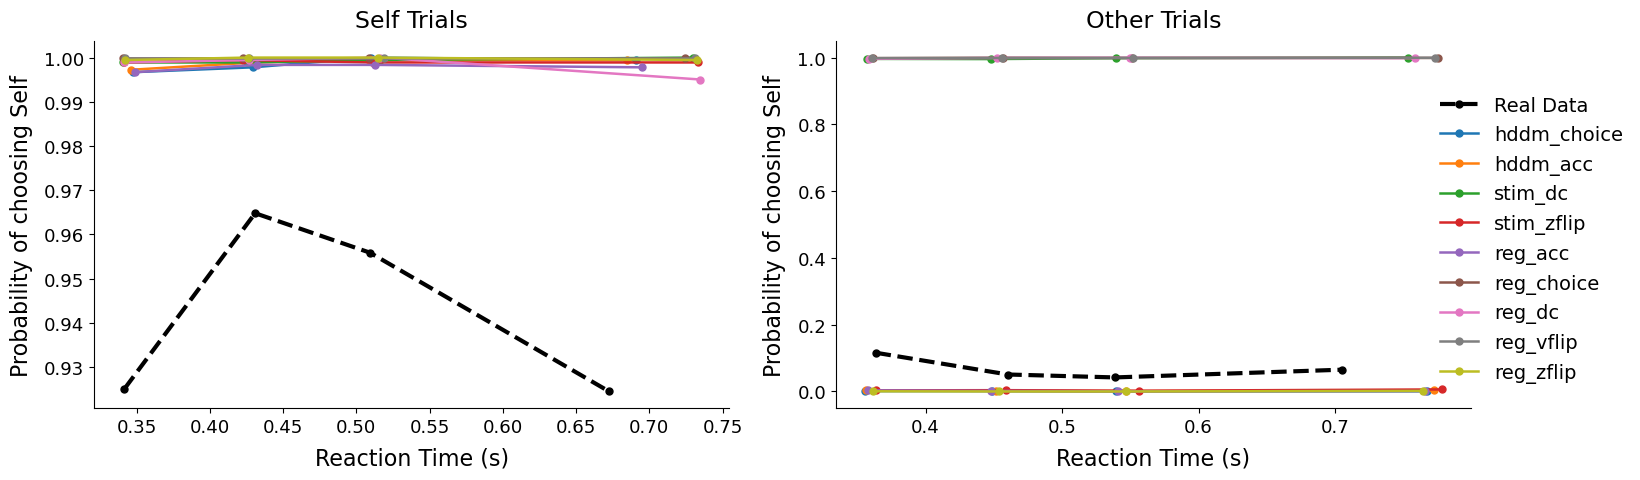

In [23]:
model_ppc_data = {
    "hddm_choice": ppc_trans_data_hddm_choice,
    "hddm_acc":    ppc_trans_data_hddm_acc,
    "stim_dc":     ppc_trans_data_stim_dc,
    "stim_zflip":  ppc_trans_data_stim_zflip,
    "reg_acc":     ppc_trans_data_reg_acc,
    "reg_choice":  ppc_trans_data_reg_choice,
    "reg_dc":      ppc_trans_data_reg_dc,
    "reg_vflip":   ppc_trans_data_reg_vflip,
    "reg_zflip":   ppc_trans_data_reg_zflip,
}

# plot
# fig = plot_crf_3_conditions(
#     real_data=data,
#     model_ppc_dict=model_ppc_data,
#     target_stim=1,
#     condition="big_bias"
# )
fig = plot_crf_2_conditions(
    real_data=data,
    model_ppc_dict=model_ppc_data
)

plt.show()
fig.savefig("CRF_model_comparison.svg", format="svg", bbox_inches="tight", dpi=300)

Plotting: hddm_choice
Plotting: hddm_acc
Plotting: stim_dc
Plotting: stim_zflip
Plotting: reg_acc
Plotting: reg_choice
Plotting: reg_dc
Plotting: reg_vflip
Plotting: reg_zflip


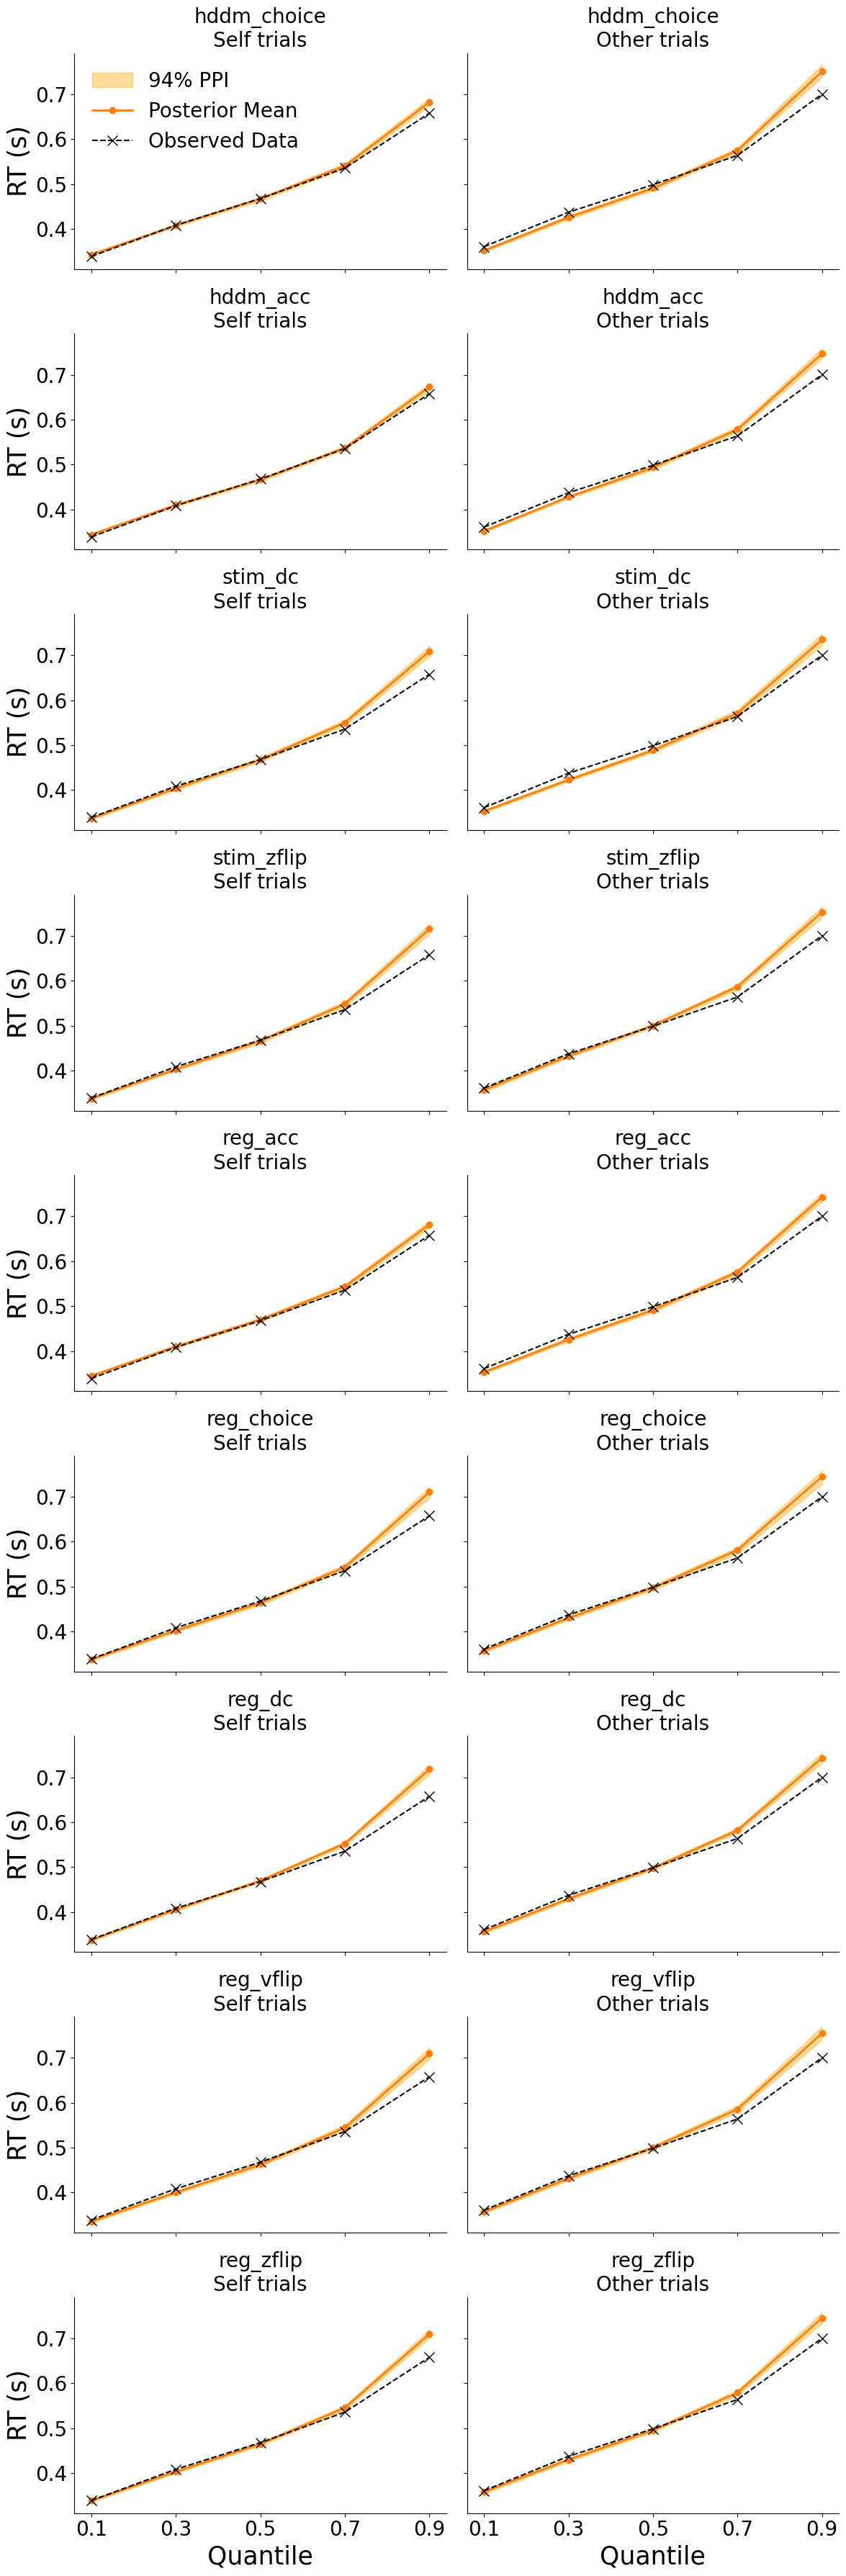

In [29]:
ppc_dict = {
    "hddm_choice": ppc_data_hddm_choice,
    "hddm_acc": ppc_data_hddm_acc,
    "stim_dc": ppc_data_stim_dc,
    "stim_zflip": ppc_data_stim_zflip,
    "reg_acc": ppc_data_reg_acc,
    "reg_choice": ppc_data_reg_choice,
    "reg_dc": ppc_data_reg_dc,
    "reg_vflip": ppc_data_reg_vflip,
    "reg_zflip": ppc_data_reg_zflip,
}


def plot_all_models_from_ppc(ppc_dict, obs_data, quantiles=[0.1, 0.3, 0.5, 0.7, 0.9]):

    plt.rcParams.update({'font.size': 14})

    model_list = list(ppc_dict.items())
    conditions = ["Self", "Other"]

    n_models = len(model_list)
    n_cols = len(conditions)
    fig, axes = plt.subplots(n_models, n_cols, figsize=(12, 4 * n_models), sharex=True, sharey=True)

    if n_models == 1:
        axes = np.array([axes])

    for model_row, (model_name, ppc) in enumerate(model_list):
        print(f"Plotting: {model_name}")

        ppc_df = ppc.reset_index()

        obs_data_reset = obs_data.reset_index(drop=True).reset_index().rename(columns={"index": "trial_idx"})
        ppc_df = ppc_df.merge(obs_data_reset[["trial_idx", "id"]], on="trial_idx", how="left")

        for col, cond in enumerate(conditions):
            ax = axes[model_row, col]
            
            # 观测数据:该 id 条件下所有试次的 RT 分位数
            obs_q = obs_data.loc[obs_data["id"] == cond, "rt"].quantile(quantiles)

            # 模型预测:该 id 条件下所有试次的 RT 绝对值分位数
            pp_sub = ppc_df[ppc_df["id"] == cond]
            pp_qs = []
            for draw in pp_sub["draw"].unique():
                vals = pp_sub[pp_sub["draw"] == draw]["rt"].abs()
                if len(vals) >= 3:
                    pp_qs.append(vals.quantile(quantiles).values)

            # ---- 以下全部对齐到 for col 这一层,退出 for draw 循环 ----
            pp_qs = np.array(pp_qs)
            m = pp_qs.mean(axis=0)
            lo = np.percentile(pp_qs, 3, axis=0)
            hi = np.percentile(pp_qs, 97, axis=0)

            ax.fill_between(quantiles, lo, hi, color="orange", alpha=0.4, label="94% PPI")
            ax.plot(quantiles, m, "o-", color="C1", lw=2, label="Posterior Mean")
            ax.plot(quantiles, obs_q, "kx--", ms=10, label="Observed Data")

            ax.set_title(f"{model_name}\n{cond} trials", fontsize=20)
            ax.grid(False)
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.tick_params(axis='both', labelsize=20)

            if model_row == n_models - 1:
                ax.set_xlabel("Quantile", fontsize=25)
                ax.set_xticks(quantiles)
            if col == 0:
                ax.set_ylabel("RT (s)", fontsize=25)

    axes[0, 0].legend(loc="upper left", fontsize=20, frameon=False)
    plt.tight_layout()
    return fig


fig = plot_all_models_from_ppc(ppc_dict=ppc_dict, obs_data=data)
fig.savefig("9_models_ppc.svg", format="svg", bbox_inches="tight", dpi=300)
plt.show()